# WM-811K — exploring wafer defect maps

Completely different problem from SECOM. Here the input isn't tabular sensor data — it's an *image* of which dies on a finished wafer failed final test. Engineers look at these images and recognize *patterns*: a circular ring of failures usually means an edge effect during processing; a scratch-shaped line of failures usually means a wafer-handling issue. Classifying those patterns is a real fab task that today is mostly still done by eye.

WM-811K is the largest open dataset for this problem: 811,457 wafer maps from a real fab, with about 172,950 of them human-labeled into eight defect-pattern classes plus a 'none' class (wafers that had some failures but no recognizable pattern).

**About running this notebook:** the dataset lives on Kaggle and is ~150 MB compressed (~2 GB unpacked). The cleanest way to grab it is via `kagglehub` (no API key needed for public datasets):

```python
import kagglehub, shutil, os
p = kagglehub.dataset_download("qingyi/wm811k-wafer-map")
shutil.copy(os.path.join(p, "LSWMD.pkl"), "../data/raw/wm811k/LSWMD.pkl")
```

The repo's `data/raw/wm811k/README.md` has the same instructions.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_io import load_wm811k

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = load_wm811k("../data/raw/wm811k/LSWMD.pkl", labeled_only=True)
print(f"labeled wafers: {len(df):,}")
print("columns:", df.columns.tolist())
df.head(3)

labeled wafers: 172,950
columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType', 'label']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType,label
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]],none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]],none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]],none


## Class distribution

Heavily imbalanced — the 'none' class (wafers with failures but no recognizable pattern) is by far the largest at 147k entries, and within the eight actual defect patterns the class sizes vary by 1–2 orders of magnitude. Near-full has just 149 wafers; Edge-Ring has nearly 10,000.

Any model I build has to be aware of this. Without class weights or some other balancing, it'll just learn to predict 'none' for everything and look great on raw accuracy.

label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


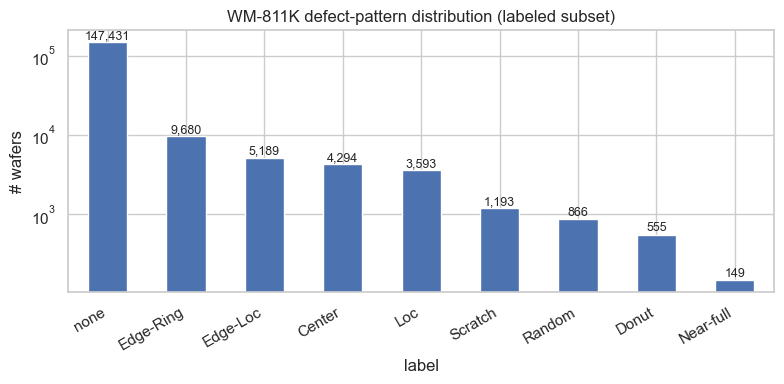

In [3]:
counts = df["label"].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind="bar", color="#4c72b0", ax=ax)
ax.set_title("WM-811K defect-pattern distribution (labeled subset)")
ax.set_ylabel("# wafers")
ax.set_yscale("log")
for i, v in enumerate(counts.values):
    ax.text(i, v * 1.1, f"{v:,}", ha="center", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

## Wafer-map shapes

Different wafers came in different physical sizes (different die counts), so the maps in the dataset are different array shapes. The CNN in the next notebook will need them at a uniform resolution, so I want to know the distribution of native shapes before picking a resize target.

In [4]:
shapes = df["waferMap"].apply(lambda w: w.shape).value_counts().head(10)
print("top 10 wafer-map shapes:")
print(shapes)

top 10 wafer-map shapes:
waferMap
(25, 27)    18781
(26, 26)    14366
(30, 34)    12400
(29, 26)    11751
(27, 25)    10682
(39, 37)    10173
(33, 29)     8125
(42, 44)     6724
(44, 41)     6134
(41, 33)     5091
Name: count, dtype: int64


## What do the patterns actually look like?

Three random examples per class. Pixel values in a wafer map are: 0 = no die at that position (outside the wafer boundary), 1 = passing die, 2 = failing die. I'm plotting with a categorical colormap so the three values are visually distinct — outside in white, pass in grey, fail in red.

**This plot is the whole reason I'm optimistic about phase 2.** Edge-Ring is *literally* a red ring around the wafer. Donut is *literally* a red donut. Near-full is *literally* almost all red. These are spatial patterns that even a small CNN should learn to recognize cleanly, because they're the same shapes a human would point to and name.

The classes I'd expect to be harder — Loc and Scratch — already look harder in this plot. A "Scratch" wafer is often just a slightly-linear cluster of failures; a "Loc" wafer is a small cluster anywhere. If I squint they can look the same. I'll come back to this in the CNN notebook.

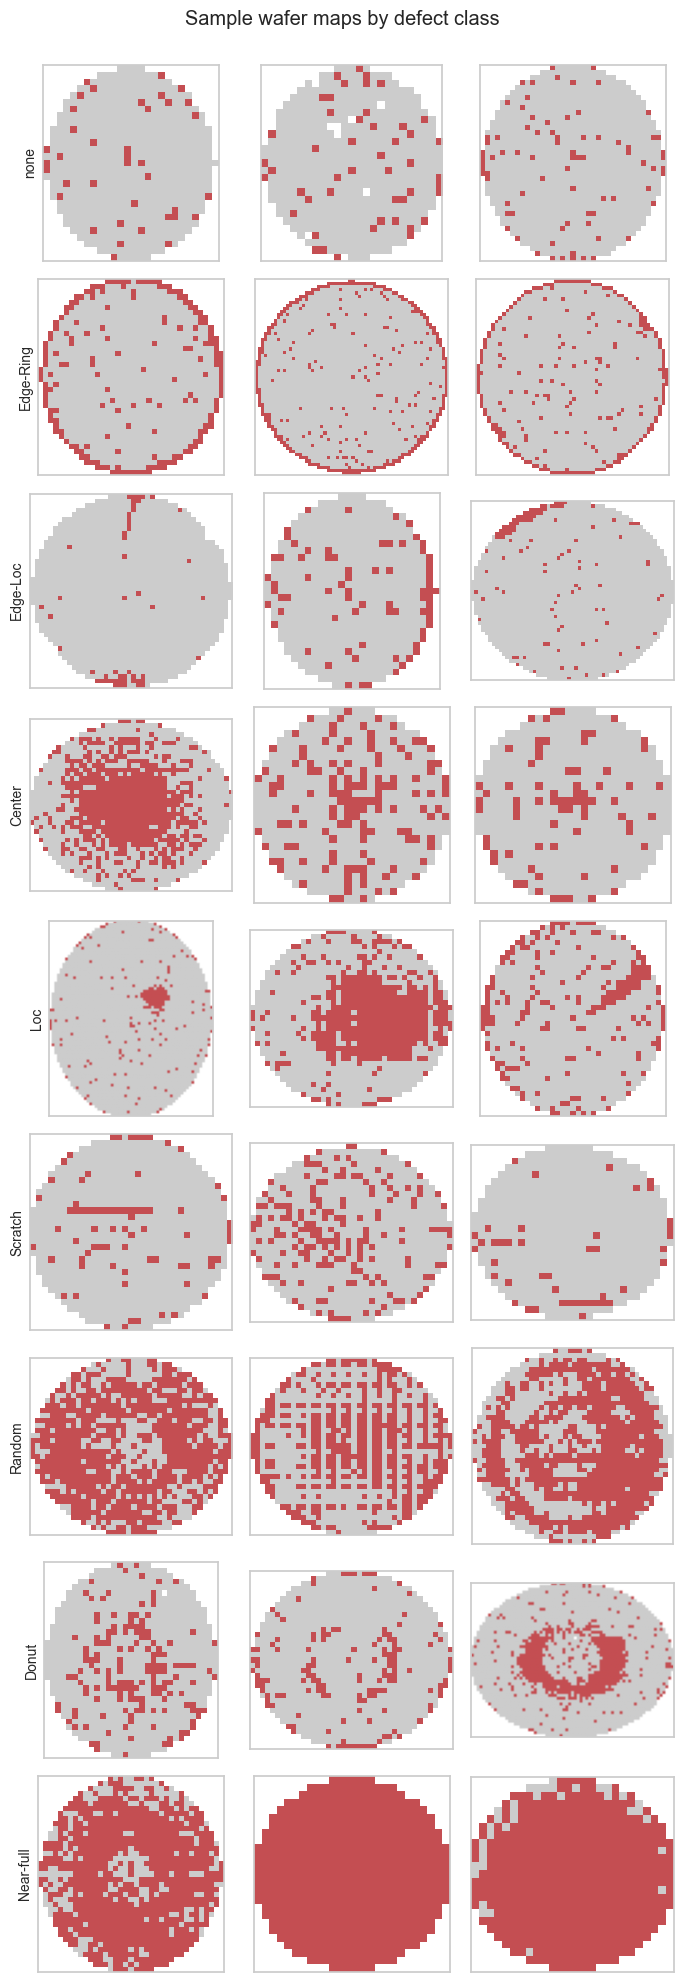

In [5]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#ffffff", "#cccccc", "#c44e52"])  # 0=outside, 1=pass, 2=fail
rng = np.random.default_rng(7)

classes = counts.index.tolist()
fig, axes = plt.subplots(len(classes), 3, figsize=(7, 2.2 * len(classes)))
for r, cls in enumerate(classes):
    pool = df.index[df["label"] == cls].tolist()
    picks = rng.choice(pool, size=min(3, len(pool)), replace=False)
    for c, idx in enumerate(picks):
        ax = axes[r, c]
        ax.imshow(df.loc[idx, "waferMap"], cmap=cmap, vmin=0, vmax=2)
        ax.set_xticks([]); ax.set_yticks([])
        if c == 0:
            ax.set_ylabel(cls, fontsize=10)
plt.suptitle("Sample wafer maps by defect class", y=1.0)
plt.tight_layout(); plt.show()

## What this tells me for the CNN notebook

- **Class imbalance is severe.** 'none' will swamp everything if I don't handle it. Class weights are the standard fix; I'll compute them from the training distribution and pass them into PyTorch's `CrossEntropyLoss`.
- **Multiple native shapes.** I'll resize to a single square resolution (64×64 for the first pass) using nearest-neighbour interpolation, so the discrete 0/1/2 pixel values stay intact rather than getting blurred together by bilinear interpolation.
- **Pattern recognition is the right framing.** The classes that look obviously distinct here (Center, Donut, Edge-Ring, Near-full) should be easy for any reasonable CNN. The ones that look ambiguous (Loc, Scratch) will probably be where the model loses macro-F1.
- **Spatial structure matters.** Conv layers should comfortably beat any flattened-pixel MLP here — the patterns are translation-invariant within the wafer, which is what convolution exploits.